# Deep Momentum Networks for Time-Series Momentum: Detailed SPY Replication

This notebook is using the ideas from Lim, Zohren, and Roberts, "Enhancing Time Series Momentum Strategies Using Deep Neural Networks"

The original paper uses many futures markets and several neural architectures. Here we build a smaller but transparent experiment using the three provided data files:

- `SPY.csv`: the tradable asset;
- `DFF.csv`: daily Federal Funds Rate;
- `FEDFUNDS.csv`: monthly Federal Funds Rate.

My goal of this notebook is to understand the method and validate the key idea on real data: train a model to output a trading position directly, then evaluate the resulting strategy.

## 1. Imports and Project Paths

Needs standard scientific Python packages: `numpy`, `pandas`, and `matplotlib`.

In [1]:
import math

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


import pandas as pd


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"


FIGURE_DIR = PROJECT_ROOT / "figures"
RESULT_DIR = PROJECT_ROOT / "results"

FIGURE_DIR.mkdir(exist_ok=True)


RESULT_DIR.mkdir(exist_ok=True)

TRADING_DAYS = 252
TARGET_VOL = 0.15
EPS = 1e-8
RANDOM_SEED = 7

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams["figure.dpi"] = 80

plt.rcParams["savefig.dpi"] = 85


## 2. Load All Three Data Files

`SPY.csv` provides the asset price. `DFF.csv` and `FEDFUNDS.csv` both describe the Federal Funds Rate, but at different frequencies. I use the daily series as a day-by-day rate environment feature and the monthly series as a smoother macro feature.

In [2]:
spy = pd.read_csv(DATA_DIR / "SPY.csv", parse_dates=["Date"])

dff = pd.read_csv(DATA_DIR / "DFF.csv", parse_dates=["DATE"]).rename(columns={"DATE": "Date", "DFF": "dff_level"})
fed = pd.read_csv(DATA_DIR / "FEDFUNDS.csv", parse_dates=["DATE"]).rename(columns={"DATE": "Date", "FEDFUNDS": "fedfunds_monthly_level"})

data_summary = pd.DataFrame({
    "Dataset": ["SPY.csv", "DFF.csv", "FEDFUNDS.csv"],
    
    "Rows": [len(spy), len(dff), len(fed)],
    
    
    "Start": [spy["Date"].min().date(), dff["Date"].min().date(), fed["Date"].min().date()],
    
    "End": [spy["Date"].max().date(), dff["Date"].max().date(), fed["Date"].max().date()],
    
    
    "Role in notebook": [
        "tradable asset: SPY adjusted close",
        
        "daily risk-free / rate environment feature",
        
        
        "monthly Fed Funds macro context feature",
    ],
})
data_summary

,Dataset,Rows,Start,End,Role in notebook
0,SPY.csv,6546,1994-01-03,2019-12-31,tradable asset: SPY adjusted close
1,DFF.csv,24002,1954-07-01,2020-03-17,daily risk-free / rate environment feature
2,FEDFUNDS.csv,788,1954-07-01,2020-02-01,monthly Fed Funds macro context feature


## 3. Visual Check of the Raw Data

Before modeling, it is useful to look at the asset price and the rate series. This also makes clear that all three files are being used.

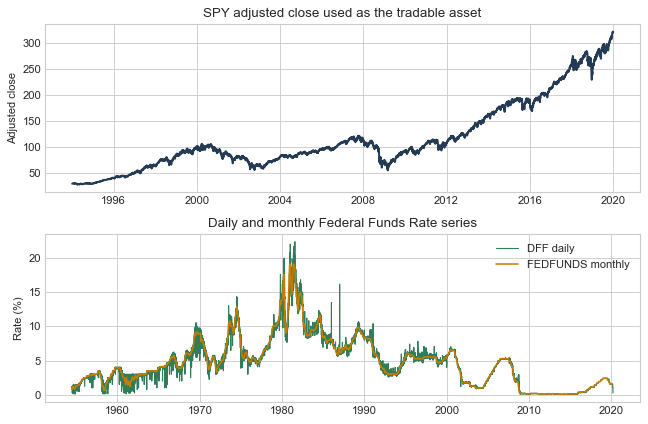

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8.2, 5.4), sharex=False)

axes[0].plot(spy["Date"], spy["Adj Close"], color="#243b53", linewidth=1.8)

axes[0].set_title("SPY adjusted close used as the tradable asset")

axes[0].set_ylabel("Adjusted close")


axes[1].plot(dff["Date"], dff["dff_level"], label="DFF daily", color="#2f7d59", linewidth=1.0)

axes[1].plot(fed["Date"], fed["fedfunds_monthly_level"], label="FEDFUNDS monthly", color="#c77d00", linewidth=1.4)
axes[1].set_title("Daily and monthly Federal Funds Rate series")


axes[1].set_ylabel("Rate (%)")

axes[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

## 4. Feature Engineering

The paper's time-series momentum setup uses lagged returns, MACD-style trend indicators, volatility estimates, and volatility scaling. This simplified version builds those same families of variables:

- normalized returns over 1 day, 1 month, 3 months, 6 months, and 12 months;
- MACD trend signals at multiple speeds;
- realized volatility and target-volatility scaling;
- daily and monthly Federal Funds Rate features.

In [4]:
FEATURE_COLUMNS = [
    "ret_1d_norm", "ret_21d_norm", "ret_63d_norm", "ret_126d_norm", "ret_252d_norm",
    "macd_8_24", "macd_16_48", "macd_32_96", "sigma_norm",
    "dff_level", "dff_change_21d",
    
    "fedfunds_monthly_level", "fedfunds_monthly_change_3m",
    "dff_minus_monthly_fedfunds",
]

spy = spy.sort_values("Date").copy()

dff = dff.sort_values("Date").copy()
fed = fed.sort_values("Date").copy()



df = spy[["Date", "Adj Close", "Volume"]].merge(dff, on="Date", how="left").sort_values("Date")
df = pd.merge_asof(df, fed, on="Date", direction="backward")
df["dff_level"] = df["dff_level"].ffill()


df["fedfunds_monthly_level"] = df["fedfunds_monthly_level"].ffill()

df["close"] = df["Adj Close"]
df["ret_1d"] = df["close"].pct_change()
df["next_ret_1d"] = df["ret_1d"].shift(-1)


df["sigma"] = df["ret_1d"].ewm(span=60, adjust=False, min_periods=60).std() * math.sqrt(TRADING_DAYS)
df["daily_sigma"] = df["sigma"] / math.sqrt(TRADING_DAYS)


df["vol_scale"] = (TARGET_VOL / df["sigma"]).clip(upper=5.0)
df["scaled_next_ret"] = df["vol_scale"] * df["next_ret_1d"]


df["ret_1d_norm"] = df["ret_1d"] / (df["daily_sigma"] + EPS)

for window in [21, 63, 126, 252]:
    raw_return = df["close"].pct_change(window)
    
    
    
    window_sigma = df["daily_sigma"] * math.sqrt(window)
    df[f"ret_{window}d_norm"] = raw_return / (window_sigma + EPS)

price_diff_vol = df["close"].diff().rolling(63, min_periods=40).std()
for short, long in [(8, 24), (16, 48), (32, 96)]:
    macd_raw = df["close"].ewm(span=short, adjust=False).mean() - df["close"].ewm(span=long, adjust=False).mean()
    macd_norm = macd_raw / (price_diff_vol + EPS)
    
    
    macd_z = macd_norm / (macd_norm.rolling(252, min_periods=120).std() + EPS)
    df[f"macd_{short}_{long}"] = macd_z.clip(-5, 5)

df["sigma_norm"] = df["sigma"] / (df["sigma"].rolling(252, min_periods=120).mean() + EPS) - 1.0
df["dff_change_21d"] = df["dff_level"].diff(21)


df["fedfunds_monthly_change_3m"] = df["fedfunds_monthly_level"].diff(63)


df["dff_minus_monthly_fedfunds"] = df["dff_level"] - df["fedfunds_monthly_level"]

df = df.dropna(subset=FEATURE_COLUMNS + ["next_ret_1d", "scaled_next_ret", "sigma"]).copy()



df.reset_index(drop=True, inplace=True)

df[["Date", "close", "ret_252d_norm", "macd_8_24", "sigma", "dff_level", "fedfunds_monthly_level"]].head(8)

,Date,close,ret_252d_norm,macd_8_24,sigma,dff_level,fedfunds_monthly_level
0,1995-01-03,28.841124,0.105931,0.415405,0.108627,5.98,5.53
1,1995-01-04,28.978922,0.113823,0.448698,0.107675,6.59,5.53
2,1995-01-05,28.978922,0.096567,0.455412,0.105897,5.72,5.53
3,1995-01-06,29.008436,0.108043,0.471886,0.104172,5.52,5.53
4,1995-01-09,29.038006,0.060816,0.494989,0.102475,5.52,5.53
5,1995-01-10,29.067511,-0.046134,0.529689,0.100804,5.44,5.53
6,1995-01-11,29.087204,-0.020277,0.572961,0.099144,5.44,5.53
7,1995-01-12,29.097054,0.016641,0.586626,0.097505,5.50,5.53


## 5. Feature Visualization

First create interpretable trend and risk features, then let the model learn how to combine them into positions.

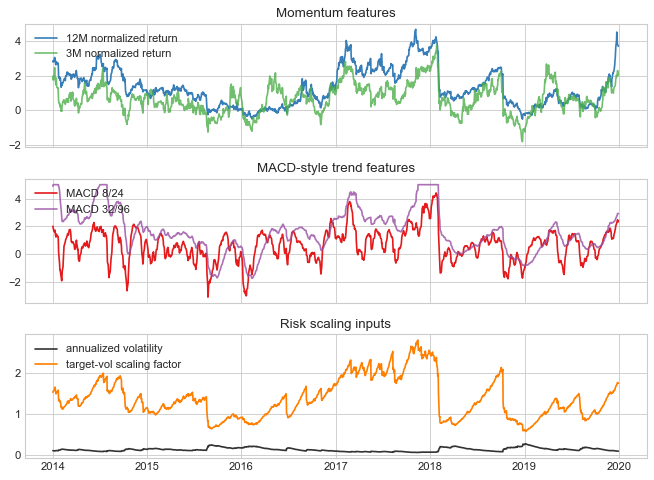

In [5]:
sample = df[(df["Date"] >= "2014-01-01") & (df["Date"] <= "2019-12-31")]
fig, axes = plt.subplots(3, 1, figsize=(8.4, 6.1), sharex=True)


axes[0].plot(sample["Date"], sample["ret_252d_norm"], label="12M normalized return", color="#377eb8")
axes[0].plot(sample["Date"], sample["ret_63d_norm"], label="3M normalized return", color="#4daf4a", alpha=0.8)
axes[0].legend(loc="upper left")


axes[0].set_title("Momentum features")
axes[1].plot(sample["Date"], sample["macd_8_24"], label="MACD 8/24", color="#e41a1c")


axes[1].plot(sample["Date"], sample["macd_32_96"], label="MACD 32/96", color="#984ea3", alpha=0.8)
axes[1].legend(loc="upper left")


axes[1].set_title("MACD-style trend features")


axes[2].plot(sample["Date"], sample["sigma"], label="annualized volatility", color="#333333")
axes[2].plot(sample["Date"], sample["vol_scale"], label="target-vol scaling factor", color="#ff7f00")
axes[2].legend(loc="upper left")


axes[2].set_title("Risk scaling inputs")
fig.tight_layout()
plt.show()

## 6. Trading Objective

For one asset, the target-volatility strategy return is:

$$
R_{t+1}=X_t \cdot \frac{\sigma_{target}}{\sigma_t}\cdot r_{t+1}.
$$

Here $X_t$ is the model's position, bounded between -1 and +1. The most important loss is negative Sharpe:

$$
\mathcal{L}(\theta)=-\frac{\sqrt{252}\bar R}{\sqrt{T^{-1}\sum_t(R_t-\bar R)^2}}.$$

In [6]:
def annualized_sharpe(returns):
    vol = returns.std(ddof=0) * math.sqrt(TRADING_DAYS)
    if vol < EPS:
        
        return 0.0
    return float(returns.mean() * TRADING_DAYS / vol)


def max_drawdown(returns):
    wealth = (1.0 + returns).cumprod()
    
    
    drawdown = wealth / wealth.cummax() - 1.0
    
    
    return float(drawdown.min())


def downside_deviation(returns):
    
    downside = np.minimum(returns.values, 0.0)
    
    
    return float(np.sqrt(np.mean(downside ** 2)) * math.sqrt(TRADING_DAYS))


def phi_baz(y):
    
    
    return (y * np.exp(-(y ** 2) / 4.0) / 0.89).clip(-1, 1)


print("Metric helpers are ready.")

Metric helpers are ready.


## 7. Define a Small Neural Network

I use a compact one-hidden-layer MLP. The final `tanh` keeps positions in `[-1, 1]`.

I also include a linear Sharpe model as a simpler benchmark between hand-crafted rules and a nonlinear MLP.

In [7]:
def init_mlp(n_features, hidden_units, seed):
    
    
    rng = np.random.default_rng(seed)
    return {
        
        
        "w1": rng.normal(0, 0.12, size=(n_features, hidden_units)),
        "b1": np.zeros(hidden_units),
        
        
        "w2": rng.normal(0, 0.12, size=(hidden_units, 1)),
        "b2": np.zeros(1),
    }


def init_linear(n_features, seed):
    
    
    rng = np.random.default_rng(seed)
    
    return {"w": rng.normal(0, 0.08, size=n_features), "b": np.zeros(1)}


def pack(params, model_type):
    if model_type == "linear":
        
        
        return np.concatenate([params["w"].ravel(), params["b"].ravel()])
    
    return np.concatenate([params["w1"].ravel(), params["b1"].ravel(), params["w2"].ravel(), params["b2"].ravel()])


def unpack(theta, n_features, model_type, hidden_units):
    if model_type == "linear":
        
        
        return {"w": theta[:n_features], "b": theta[n_features : n_features + 1]}
    i = 0
    w1 = theta[i : i + n_features * hidden_units].reshape(n_features, hidden_units)
    i += n_features * hidden_units  
    
    
    b1 = theta[i : i + hidden_units]
    
    
    i += hidden_units
    w2 = theta[i : i + hidden_units].reshape(hidden_units, 1)
    i += hidden_units
    
    b2 = theta[i : i + 1]
    return {"w1": w1, "b1": b1, "w2": w2, "b2": b2}


def forward(theta, x, model_type="mlp", hidden_units=6):
    
    params = unpack(theta, x.shape[1], model_type, hidden_units)
    if model_type == "linear":
        
        
        z = x @ params["w"] + params["b"][0]
        pos = np.tanh(z)
        return pos, {"params": params, "z": z, "x": x}
    z1 = x @ params["w1"] + params["b1"]
    
    
    h = np.tanh(z1)
    z2 = h @ params["w2"] + params["b2"]
    pos = np.tanh(z2).ravel()
    
    
    
    
    return pos, {"params": params, "z1": z1, "h": h, "z2": z2, "x": x}


print("Model helpers are ready.")

Model helpers are ready.


## 8. Define Four Training Objectives


- `sharpe`: directly maximize strategy Sharpe;
- `avg_return`: maximize average strategy return;
- `mse`: learn a continuous return-like signal;
- `binary`: learn the sign of the next return.

In [8]:
def position_loss_gradient(pos, y, objective, target_scale):
    n = len(y)
    strategy_returns = pos * y
    
    if objective == "sharpe":
        
        
        mean_r = strategy_returns.mean()
        centered = strategy_returns - mean_r
        
        
        std_r = math.sqrt(float(np.mean(centered ** 2)) + EPS)
        
        sharpe = math.sqrt(TRADING_DAYS) * mean_r / std_r
        
        
        d_sharpe_d_returns = (math.sqrt(TRADING_DAYS) / n) * (
            
            1.0 / std_r - (mean_r * centered) / (std_r ** 3)
            
            
        )
        return -float(sharpe), -d_sharpe_d_returns * y, float(sharpe)

    if objective == "avg_return":
        
        
        return -float(strategy_returns.mean() * TRADING_DAYS), -y / n, annualized_sharpe(strategy_returns)

    if objective == "mse":
        target = np.tanh(y / (target_scale + EPS))
        
        
    elif objective == "binary":
        target = np.where(y >= 0, 1.0, -1.0)
        
    else:
        
        
        
        raise ValueError(f"Unknown objective: {objective}")

    diff = pos - target
    return float(np.mean(diff ** 2)), 2.0 * diff / n, annualized_sharpe(strategy_returns)



def loss_and_grad(theta, x, y, objective, model_type, hidden_units, l2, target_scale):
    pos, cache = forward(theta, x, model_type, hidden_units)
    
    
    
    loss, dloss_dpos, train_sharpe = position_loss_gradient(pos, y, objective, target_scale)

    if model_type == "linear":
        params = cache["params"]
        
        
        
        dz = dloss_dpos * (1.0 - pos ** 2)
        grad_w = x.T @ dz + 2.0 * l2 * params["w"]
        
        
        grad_b = np.array([dz.sum()])
        return loss + l2 * np.sum(params["w"] ** 2), np.concatenate([grad_w.ravel(), grad_b.ravel()]), train_sharpe

    params = cache["params"]
    h = cache["h"]
    
    
    dz2 = dloss_dpos.reshape(-1, 1) * (1.0 - pos.reshape(-1, 1) ** 2)
    
    
    grad_w2 = h.T @ dz2 + 2.0 * l2 * params["w2"]
    grad_b2 = dz2.sum(axis=0)
    
    
    dh = dz2 @ params["w2"].T
    dz1 = dh * (1.0 - h ** 2)
    
    
    
    grad_w1 = x.T @ dz1 + 2.0 * l2 * params["w1"]
    grad_b1 = dz1.sum(axis=0)
    
    
    reg = l2 * (np.sum(params["w1"] ** 2) + np.sum(params["w2"] ** 2))
    
    
    grad = np.concatenate([grad_w1.ravel(), grad_b1.ravel(), grad_w2.ravel(), grad_b2.ravel()])
    return loss + reg, grad, train_sharpe


def train_model(x_train, y_train, x_val, y_val, objective, model_type, seed,
                hidden_units=6, epochs=650, learning_rate=0.01, l2=5e-4, patience=100):
    
    
    
    
    
    theta = pack(init_linear(x_train.shape[1], seed), model_type) if model_type == "linear" else pack(init_mlp(x_train.shape[1], hidden_units, seed), model_type)
    m = np.zeros_like(theta)
    
    
    v = np.zeros_like(theta)
    beta1, beta2 = 0.9, 0.999
    best_theta = theta.copy()
    
    
    
    best_val = -np.inf
    wait = 0
    
    
    target_scale = float(np.std(y_train)) + EPS
    history = []

    for epoch in range(1, epochs + 1):
        loss, grad, train_score = loss_and_grad(theta, x_train, y_train, objective, model_type, hidden_units, l2, target_scale)
        m = beta1 * m + (1.0 - beta1) * grad
        
        
        v = beta2 * v + (1.0 - beta2) * (grad ** 2)
        theta = theta - learning_rate * (m / (1.0 - beta1 ** epoch)) / (np.sqrt(v / (1.0 - beta2 ** epoch)) + EPS)

        if epoch % 5 == 0 or epoch == 1:
            val_pos, _ = forward(theta, x_val, model_type, hidden_units)
            
            
            
            val_sharpe = annualized_sharpe(val_pos * y_val)
            history.append({"epoch": epoch, "objective_loss": loss, "train_strategy_sharpe": train_score, "validation_sharpe": val_sharpe})
            if val_sharpe > best_val:
                best_val = val_sharpe
                
                
                
                best_theta = theta.copy()
                wait = 0
            else:
                wait += 5
            if wait >= patience:
                break
    return best_theta, pd.DataFrame(history)


print("Training functions are ready.")

Training functions are ready.


## 9. Walk-Forward Cross-Validation Design



1. train on data from 1996 up to three years before the test year;
2. validate on the three years immediately before the test year;
3. test on the next untouched calendar year.



In [9]:
split_rows = []
for year in range(2015, 2020):
    train = df[(df["Date"] >= "1996-01-01") & (df["Date"] < f"{year - 3}-01-01")]
    
    
    val = df[(df["Date"] >= f"{year - 3}-01-01") & (df["Date"] < f"{year}-01-01")]
    
    test = df[(df["Date"] >= f"{year}-01-01") & (df["Date"] < f"{year + 1}-01-01")]
    split_rows.append({
        "test_year": year,
        "train_rows": len(train),
        
        
        "validation_rows": len(val),
        "test_rows": len(test),
        
        
        "train_end": train["Date"].max().date(),
        
        "validation_start": val["Date"].min().date(),
        
        
    })
pd.DataFrame(split_rows)

,test_year,train_rows,validation_rows,test_rows,train_end,validation_start
0,2015,4030,754,252,2011-12-30,2012-01-03
1,2016,4280,756,252,2012-12-31,2013-01-02
2,2017,4532,756,251,2013-12-31,2014-01-02
3,2018,4784,755,251,2014-12-31,2015-01-02
4,2019,5036,754,251,2015-12-31,2016-01-04


## 10. Train the Walk-Forward Models

This cell trains a linear Sharpe model and four MLP variants. The output is a compact summary of validation Sharpe by model and test year.

In [10]:
def get_scaler(train):
    mu = train[FEATURE_COLUMNS].mean()
    
    
    
    sd = train[FEATURE_COLUMNS].std().replace(0, 1)
    
    
    return mu, sd


def apply_scaler(frame, mu, sd):
    
    return ((frame[FEATURE_COLUMNS] - mu) / sd).values.astype(float)


def add_reference_positions(frame):
    out = frame.copy()
    
    
    out["LONG ONLY"] = 1.0
    out["SGN(RETURN)"] = np.sign(out["ret_252d_norm"]).replace(0, np.nan).fillna(0.0)
    out["MACD"] = pd.concat(
        
        
        
        [phi_baz(out["macd_8_24"]), phi_baz(out["macd_16_48"]), phi_baz(out["macd_32_96"])],
        axis=1,
        
        
    ).mean(axis=1)
    return out


model_specs = [
    ("LINEAR", "linear", "sharpe"),
    
    ("MLP-SHARPE", "mlp", "sharpe"),
    
    
    
    ("MLP-AVGRET", "mlp", "avg_return"),
    ("MLP-MSE", "mlp", "mse"),
    
    
    ("MLP-BINARY", "mlp", "binary"),
]

rows = []
histories = []
for year in range(2015, 2020):
    train_end = pd.Timestamp(f"{year - 3}-01-01")
    
    
    test_start = pd.Timestamp(f"{year}-01-01")
    
    
    test_end = pd.Timestamp(f"{year + 1}-01-01")
    
    
    train = df[(df["Date"] >= "1996-01-01") & (df["Date"] < train_end)].copy()
    val = df[(df["Date"] >= train_end) & (df["Date"] < test_start)].copy()
    
    
    
    test = df[(df["Date"] >= test_start) & (df["Date"] < test_end)].copy()
    mu, sd = get_scaler(train)
    x_train = apply_scaler(train, mu, sd)
    
    
    
    x_val = apply_scaler(val, mu, sd)
    
    
    x_test = apply_scaler(test, mu, sd)
    y_train = train["scaled_next_ret"].values.astype(float)
    
    
    y_val = val["scaled_next_ret"].values.astype(float)
    
    

    scored = add_reference_positions(test)
    
    
    for j, (label, model_type, objective) in enumerate(model_specs):
        theta, history = train_model(
            x_train, y_train, x_val, y_val,
            
            
            
            objective=objective,
            model_type=model_type,
            
            
            seed=RANDOM_SEED + 100 * year + j,
        )
        scored[label] = forward(theta, x_test, model_type=model_type, hidden_units=6)[0]
        histories.append({
            "test_year": year,
            
            
            
            "model": label,
            
            
            "objective": objective,
            "best_validation_sharpe": history["validation_sharpe"].max(),
            
            
            "epochs_run": int(history["epoch"].max()),
            
            "final_train_strategy_sharpe": float(history["train_strategy_sharpe"].iloc[-1]),
        })
    scored["test_year"] = year
    
    rows.append(scored)
    

test_scored = pd.concat(rows, ignore_index=True)
history_summary = pd.DataFrame(histories)


history_summary

,test_year,model,objective,best_validation_sharpe,epochs_run,final_train_strategy_sharpe
0,2015,LINEAR,sharpe,1.501874,115,0.988112
1,2015,MLP-SHARPE,sharpe,1.472871,110,2.735828
2,2015,MLP-AVGRET,avg_return,1.401099,115,0.453716
3,2015,MLP-MSE,mse,1.484244,195,2.343538
4,2015,MLP-BINARY,binary,2.177038,100,1.074846
5,2016,LINEAR,sharpe,1.080664,170,0.945304
6,2016,MLP-SHARPE,sharpe,1.300578,140,2.556726
7,2016,MLP-AVGRET,avg_return,1.066847,110,0.481194
8,2016,MLP-MSE,mse,0.992800,125,1.540934
9,2016,MLP-BINARY,binary,1.152730,185,2.259682


## 11. Inspect the Learned Positions

The model outputs are trading positions, not class probabilities. A value near +1 means strongly long SPY, near -1 means strongly short SPY, and near 0 means low exposure.

In [11]:
position_preview = test_scored[[
    "Date", "LONG ONLY", "SGN(RETURN)", "MACD", "LINEAR",
    
    
    "MLP-SHARPE", "MLP-AVGRET", "MLP-MSE", "MLP-BINARY"
]].head(8)
position_preview

,Date,LONG ONLY,SGN(RETURN),MACD,LINEAR,MLP-SHARPE,MLP-AVGRET,MLP-MSE,MLP-BINARY
0,2015-01-02,1.0,1.0,0.833203,0.347420,0.122269,0.197882,0.076799,0.089004
1,2015-01-05,1.0,1.0,0.706803,0.645409,0.339024,0.233468,0.126366,0.170975
2,2015-01-06,1.0,1.0,0.523950,0.537562,0.300272,0.231534,0.115544,0.153225
3,2015-01-07,1.0,1.0,0.458895,0.162375,0.085058,0.200519,0.052252,0.077971
4,2015-01-08,1.0,1.0,0.530673,0.033029,0.012216,0.178911,0.050892,0.108615
5,2015-01-09,1.0,1.0,0.527821,0.533429,0.260815,0.209024,0.113159,0.169648
6,2015-01-12,1.0,1.0,0.465579,0.529044,0.259340,0.204412,0.110273,0.179005
7,2015-01-13,1.0,1.0,0.394318,0.487267,0.216528,0.203084,0.097360,0.140234


## 12. Build Raw and Target-Volatility-Rescaled Strategy Returns

Reports both raw signal outputs and returns rescaled to target volatility. 

- raw: `position × next SPY return`;
- rescaled: `position × target_vol / realized_vol × next SPY return`.

A 1 bp turnover cost is subtracted for realism.

In [12]:
labels = ["LONG ONLY", "SGN(RETURN)", "MACD", "LINEAR", "MLP-SHARPE", "MLP-AVGRET", "MLP-MSE", "MLP-BINARY"]

def strategy_returns(frame, labels, scaled, cost_bps=1.0):
    
    
    base = "scaled_next_ret" if scaled else "next_ret_1d"
    out = pd.DataFrame({"Date": frame["Date"], "test_year": frame["test_year"]})
    cost_rate = cost_bps / 10000.0
    
    
    for label in labels:
        pos = frame[label].astype(float)
        turnover = pos.diff().abs().fillna(0.0)
        
        
        turnover = turnover.where(frame["test_year"].eq(frame["test_year"].shift(1)), 0.0)
        
        
        
        out[label] = pos * frame[base] - cost_rate * turnover
    return out


def metric_row(returns, positions, strategy, year):
    ann_return = float(returns.mean() * TRADING_DAYS)
    
    
    
    ann_vol = float(returns.std(ddof=0) * math.sqrt(TRADING_DAYS))
    dd = downside_deviation(returns)
    
    
    mdd = max_drawdown(returns)
    
    
    sharpe = 0.0 if ann_vol < EPS else ann_return / ann_vol
    sortino = 0.0 if dd < EPS else ann_return / dd
    
    
    calmar = 0.0 if abs(mdd) < EPS else ann_return / abs(mdd)
    gains = returns[returns > 0]
    
    
    losses = returns[returns < 0]
    
    avg_profit_loss = 0.0 if len(losses) == 0 else float(gains.mean() / abs(losses.mean()))
    
    
    turnover = float(positions.diff().abs().fillna(0.0).mean())
    return {
        "year": year,
        "Strategy": strategy,
        "E[Return]": ann_return,
        
        
        
        "Vol.": ann_vol,
        "Downside Deviation": dd,
        
        
        "MDD": mdd,
        "Sharpe": sharpe,
        
        
        "Sortino": sortino,
        "Calmar": calmar,
        "Fraction +ve Returns": float((returns > 0).mean()),
        "Ave. Profit / Ave. Loss": avg_profit_loss,
        
        
        
        "Turnover": turnover,
        "Ave. Position": float(positions.abs().mean()),
    }


def per_year_metrics(test_scored, returns, labels):
    rows = []
    for year, year_returns in returns.groupby("test_year"):
        year_pos = test_scored[test_scored["test_year"] == year]
        for label in labels:
            rows.append(metric_row(year_returns[label], year_pos[label], label, int(year)))
    return pd.DataFrame(rows)


def aggregate_metrics(yearly):
    metrics = ["E[Return]", "Vol.", "Downside Deviation", "MDD", "Sharpe", "Sortino", "Calmar", "Fraction +ve Returns", "Ave. Profit / Ave. Loss", "Turnover", "Ave. Position"]
    rows = []
    for strategy, group in yearly.groupby("Strategy", sort=False):
        
        
        row = {"Strategy": strategy}
        for metric in metrics:
            
            
            
            row[metric] = f"{group[metric].mean():.3f} +/- {group[metric].std(ddof=0):.3f}"
            
            
        rows.append(row)
    return pd.DataFrame(rows)


returns_raw = strategy_returns(test_scored, labels, scaled=False)



returns_scaled = strategy_returns(test_scored, labels, scaled=True)
yearly_raw = per_year_metrics(test_scored, returns_raw, labels)
yearly_scaled = per_year_metrics(test_scored, returns_scaled, labels)
agg_raw = aggregate_metrics(yearly_raw)



agg_scaled = aggregate_metrics(yearly_scaled)
final_metrics = pd.DataFrame([metric_row(returns_scaled[label], test_scored[label], label, 0) for label in labels]).drop(columns=["year"])

display_metrics = final_metrics.copy()
for col in ["E[Return]", "Vol.", "Downside Deviation", "MDD", "Fraction +ve Returns", "Turnover", "Ave. Position"]:
    display_metrics[col] = display_metrics[col].map(lambda x: f"{100*x:.2f}%")
    
    
    
for col in ["Sharpe", "Sortino", "Calmar", "Ave. Profit / Ave. Loss"]:
    display_metrics[col] = display_metrics[col].map(lambda x: f"{x:.2f}")

test_scored.to_csv(RESULT_DIR / "enhanced_walk_forward_positions.csv", index=False)
returns_raw.to_csv(RESULT_DIR / "enhanced_raw_strategy_returns.csv", index=False)



returns_scaled.to_csv(RESULT_DIR / "enhanced_scaled_strategy_returns.csv", index=False)
history_summary.to_csv(RESULT_DIR / "enhanced_validation_summary.csv", index=False)



agg_raw.to_csv(RESULT_DIR / "enhanced_cv_table_raw.csv", index=False)



agg_scaled.to_csv(RESULT_DIR / "enhanced_cv_table_scaled.csv", index=False)
final_metrics.to_csv(RESULT_DIR / "enhanced_final_metrics.csv", index=False)

print("Raw and scaled return matrices are ready.")

Raw and scaled return matrices are ready.


## 13. Final Out-of-Sample Metrics

This table is the main numerical result for the simplified SPY experiment. It uses 2015-2019 target-volatility-rescaled returns after turnover cost.

In [13]:
display_metrics

,Strategy,E[Return],Vol.,Downside Deviation,MDD,Sharpe,Sortino,Calmar,Fraction +ve Returns,Ave. Profit / Ave. Loss,Turnover,Ave. Position
0,LONG ONLY,14.33%,15.54%,11.45%,-22.09%,0.92,1.25,0.65,54.42%,0.98,0.00%,100.00%
1,SGN(RETURN),6.19%,15.57%,11.76%,-36.23%,0.40,0.53,0.17,52.19%,0.98,5.41%,100.00%
2,MACD,0.90%,8.90%,6.85%,-17.39%,0.10,0.13,0.05,51.87%,0.95,4.27%,56.35%
3,LINEAR,2.25%,7.73%,5.99%,-15.78%,0.29,0.37,0.14,52.35%,0.98,16.74%,32.12%
4,MLP-SHARPE,0.37%,2.94%,2.36%,-5.25%,0.12,0.15,0.07,52.11%,0.95,5.76%,10.79%
5,MLP-AVGRET,4.75%,10.25%,7.92%,-21.71%,0.46,0.60,0.22,55.05%,0.92,1.24%,46.08%
6,MLP-MSE,0.03%,1.21%,0.99%,-2.51%,0.03,0.03,0.01,51.47%,0.95,2.25%,4.61%
7,MLP-BINARY,1.35%,2.37%,1.82%,-3.78%,0.57,0.74,0.36,52.98%,1.01,3.03%,11.46%


## 14. Paper-Style Exhibit 4: Cumulative Returns

Compares cumulative returns for several objectives after rescaling to target volatility. The figure below follows that structure using our SPY-only experiment.

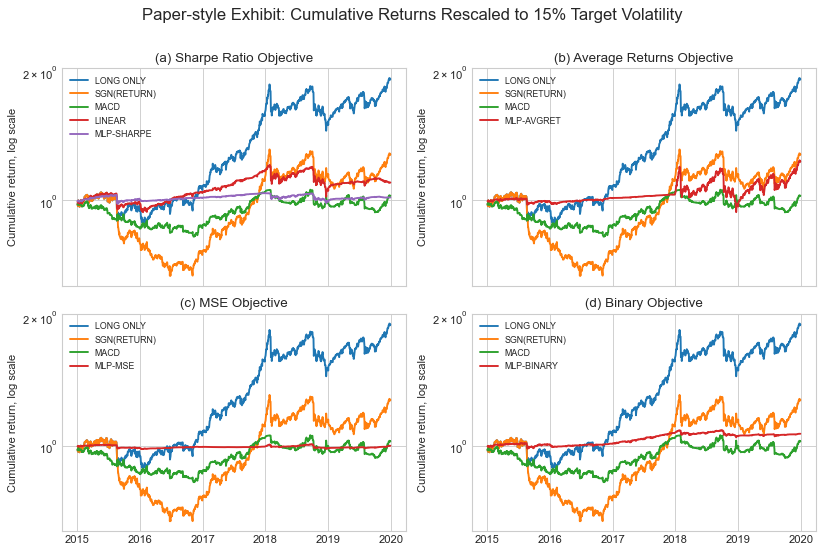

In [14]:
panel_map = {
    "(a) Sharpe Ratio Objective": ["LONG ONLY", "SGN(RETURN)", "MACD", "LINEAR", "MLP-SHARPE"],
    
    
    "(b) Average Returns Objective": ["LONG ONLY", "SGN(RETURN)", "MACD", "MLP-AVGRET"],
    "(c) MSE Objective": ["LONG ONLY", "SGN(RETURN)", "MACD", "MLP-MSE"],
    
    
    "(d) Binary Objective": ["LONG ONLY", "SGN(RETURN)", "MACD", "MLP-BINARY"],
}
fig, axes = plt.subplots(2, 2, figsize=(10.4, 6.8), sharex=True)
for ax, (title, labels_for_panel) in zip(axes.ravel(), panel_map.items()):
    
    
    
    wealth = returns_scaled.set_index("Date")[labels_for_panel].add(1).cumprod()
    for label in labels_for_panel:
        ax.plot(wealth.index, wealth[label], label=label, linewidth=1.7)
        
        
    ax.set_yscale("log")
    ax.set_title(title)
    
    
    ax.set_ylabel("Cumulative return, log scale")
    ax.legend(fontsize=8, loc="upper left")
    
    
    
fig.suptitle("Paper-style Exhibit: Cumulative Returns Rescaled to 15% Target Volatility", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

## 15. Validation Performance by Year

This plot makes the walk-forward process more transparent. Strong validation performance does not guarantee strong future performance, but it is how we select the model without looking at the test year.

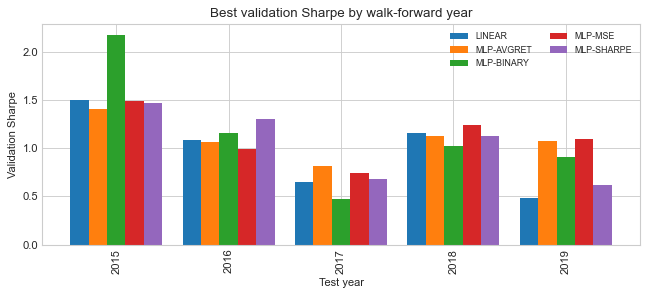

In [15]:
pivot = history_summary.pivot(index="test_year", columns="model", values="best_validation_sharpe")



fig, ax = plt.subplots(figsize=(8.2, 3.8))


pivot.plot(kind="bar", ax=ax, width=0.82)


ax.set_title("Best validation Sharpe by walk-forward year")
ax.set_ylabel("Validation Sharpe")



ax.set_xlabel("Test year")


ax.legend(loc="upper right", ncol=2, fontsize=8)
fig.tight_layout()


plt.show()

## 16.  Cross-Validation Tables

The report screenshots show raw signal and target-volatility-rescaled performance tables. The table image below follows that format with mean `+/-` standard deviation across the five walk-forward test years.

In [16]:
agg_raw

,Strategy,E[Return],Vol.,Downside Deviation,MDD,Sharpe,Sortino,Calmar,Fraction +ve Returns,Ave. Profit / Ave. Loss,Turnover,Ave. Position
0,LONG ONLY,0.119 +/- 0.118,0.129 +/- 0.035,0.092 +/- 0.029,-0.099 +/- 0.056,1.229 +/- 1.224,1.860 +/- 1.882,2.661 +/- 2.936,0.544 +/- 0.039,1.044 +/- 0.142,0.000 +/- 0.000,1.000 +/- 0.000
1,SGN(RETURN),0.011 +/- 0.143,0.129 +/- 0.035,0.098 +/- 0.031,-0.135 +/- 0.076,0.421 +/- 1.469,0.736 +/- 2.186,1.515 +/- 3.109,0.522 +/- 0.042,0.992 +/- 0.146,0.052 +/- 0.060,1.000 +/- 0.000
2,MACD,-0.008 +/- 0.078,0.076 +/- 0.020,0.057 +/- 0.016,-0.073 +/- 0.036,0.210 +/- 1.274,0.337 +/- 1.771,1.042 +/- 2.595,0.519 +/- 0.043,0.973 +/- 0.127,0.043 +/- 0.012,0.563 +/- 0.050
3,LINEAR,0.026 +/- 0.046,0.067 +/- 0.040,0.047 +/- 0.032,-0.059 +/- 0.048,1.030 +/- 1.212,1.844 +/- 2.173,2.397 +/- 2.893,0.522 +/- 0.038,1.209 +/- 0.296,0.167 +/- 0.011,0.321 +/- 0.146
4,MLP-SHARPE,0.009 +/- 0.017,0.024 +/- 0.016,0.017 +/- 0.013,-0.021 +/- 0.019,1.014 +/- 1.042,1.670 +/- 1.713,2.311 +/- 2.608,0.520 +/- 0.034,1.182 +/- 0.147,0.057 +/- 0.030,0.108 +/- 0.049
5,MLP-AVGRET,0.054 +/- 0.112,0.069 +/- 0.064,0.050 +/- 0.048,-0.060 +/- 0.069,1.330 +/- 1.352,2.216 +/- 2.408,3.363 +/- 4.177,0.550 +/- 0.043,1.089 +/- 0.193,0.011 +/- 0.010,0.461 +/- 0.428
6,MLP-MSE,0.002 +/- 0.009,0.009 +/- 0.005,0.007 +/- 0.004,-0.010 +/- 0.007,0.413 +/- 0.928,0.686 +/- 1.377,0.715 +/- 1.254,0.512 +/- 0.045,1.050 +/- 0.120,0.022 +/- 0.011,0.046 +/- 0.020
7,MLP-BINARY,0.011 +/- 0.013,0.020 +/- 0.010,0.014 +/- 0.007,-0.017 +/- 0.011,0.988 +/- 1.159,1.578 +/- 1.951,2.370 +/- 3.492,0.528 +/- 0.031,1.117 +/- 0.187,0.030 +/- 0.005,0.115 +/- 0.038


The next table is the same calculation after target-volatility rescaling.

In [17]:
agg_scaled

,Strategy,E[Return],Vol.,Downside Deviation,MDD,Sharpe,Sortino,Calmar,Fraction +ve Returns,Ave. Profit / Ave. Loss,Turnover,Ave. Position
0,LONG ONLY,0.143 +/- 0.174,0.154 +/- 0.019,0.113 +/- 0.020,-0.117 +/- 0.060,1.028 +/- 1.186,1.527 +/- 1.789,2.312 +/- 2.803,0.544 +/- 0.039,1.008 +/- 0.135,0.000 +/- 0.000,1.000 +/- 0.000
1,SGN(RETURN),0.062 +/- 0.210,0.154 +/- 0.019,0.116 +/- 0.020,-0.142 +/- 0.065,0.452 +/- 1.407,0.755 +/- 2.072,1.583 +/- 3.009,0.522 +/- 0.042,0.998 +/- 0.136,0.052 +/- 0.060,1.000 +/- 0.000
2,MACD,0.009 +/- 0.112,0.089 +/- 0.005,0.068 +/- 0.006,-0.089 +/- 0.032,0.139 +/- 1.283,0.232 +/- 1.723,0.826 +/- 2.209,0.519 +/- 0.043,0.964 +/- 0.118,0.043 +/- 0.012,0.563 +/- 0.050
3,LINEAR,0.022 +/- 0.073,0.068 +/- 0.036,0.050 +/- 0.032,-0.066 +/- 0.052,0.850 +/- 1.315,1.528 +/- 2.244,1.898 +/- 2.802,0.523 +/- 0.041,1.130 +/- 0.234,0.167 +/- 0.011,0.321 +/- 0.146
4,MLP-SHARPE,0.004 +/- 0.024,0.025 +/- 0.015,0.019 +/- 0.014,-0.025 +/- 0.021,0.787 +/- 1.128,1.277 +/- 1.690,1.774 +/- 2.385,0.521 +/- 0.033,1.099 +/- 0.134,0.057 +/- 0.030,0.108 +/- 0.049
5,MLP-AVGRET,0.048 +/- 0.097,0.075 +/- 0.070,0.057 +/- 0.055,-0.070 +/- 0.079,1.189 +/- 1.357,1.936 +/- 2.321,2.918 +/- 3.833,0.551 +/- 0.044,1.055 +/- 0.189,0.011 +/- 0.010,0.461 +/- 0.428
6,MLP-MSE,0.000 +/- 0.010,0.011 +/- 0.006,0.008 +/- 0.005,-0.012 +/- 0.009,0.359 +/- 0.880,0.602 +/- 1.185,0.609 +/- 0.980,0.515 +/- 0.045,1.026 +/- 0.136,0.022 +/- 0.011,0.046 +/- 0.020
7,MLP-BINARY,0.013 +/- 0.025,0.022 +/- 0.008,0.017 +/- 0.007,-0.020 +/- 0.012,0.810 +/- 1.179,1.276 +/- 1.911,2.009 +/- 3.342,0.530 +/- 0.031,1.070 +/- 0.193,0.030 +/- 0.005,0.115 +/- 0.038


For easier presentation, the two cross-validation tables are also rendered as one paper-style image.

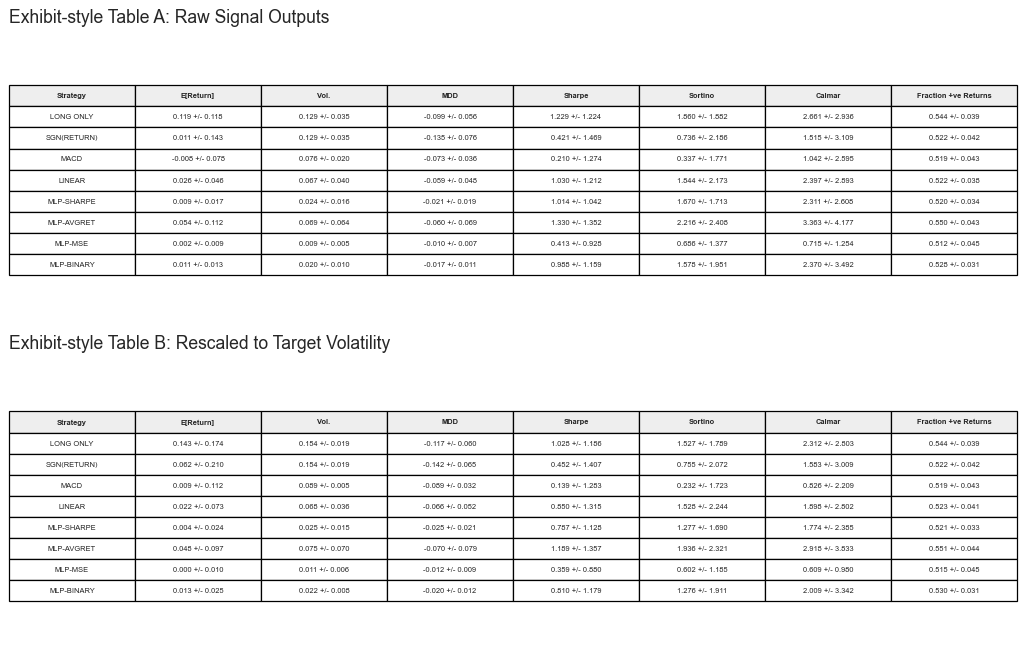

In [18]:
from IPython.display import Image
Image(filename=str(FIGURE_DIR / "enhanced_exhibit10_11_tables.png"))

## 17. Drawdowns

 This plot compares major strategies after target-volatility rescaling.

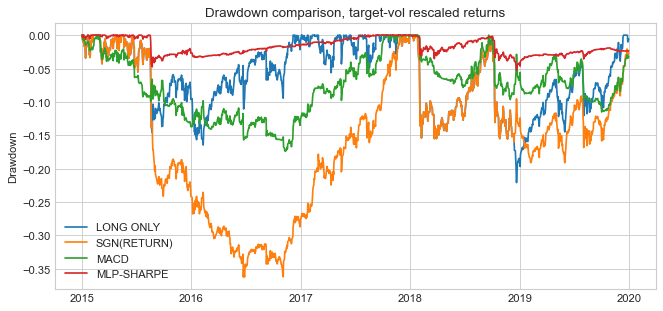

In [19]:
fig, ax = plt.subplots(figsize=(8.4, 4.0))
for label in ["LONG ONLY", "SGN(RETURN)", "MACD", "MLP-SHARPE"]:
    
    
    
    wealth = (1.0 + returns_scaled[label]).cumprod()
    
    drawdown = wealth / wealth.cummax() - 1.0
    
    ax.plot(returns_scaled["Date"], drawdown, label=label, linewidth=1.5)
    
    
ax.set_title("Drawdown comparison, target-vol rescaled returns")
ax.set_ylabel("Drawdown")


ax.legend(loc="lower left")


fig.tight_layout()
plt.show()

## 18. Sharpe Comparison

 The more relevant comparison is against hand-crafted trend-following rules.

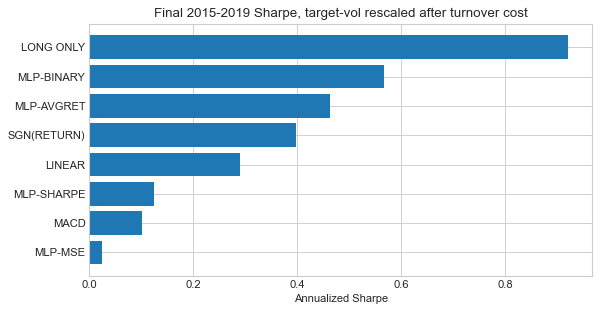

In [20]:
order = final_metrics.sort_values("Sharpe", ascending=True)
fig, ax = plt.subplots(figsize=(7.6, 4.0))


ax.barh(order["Strategy"], order["Sharpe"])

ax.set_title("Final 2015-2019 Sharpe, target-vol rescaled after turnover cost")



ax.set_xlabel("Annualized Sharpe")
fig.tight_layout()
plt.show()

## 20. Multi-Asset / Equity-Panel Real-Data Test

The SPY-only experiment is useful for understanding the code, but the original paper validates DMNs on a diversified futures universe. The exact futures database is not freely available here, so I add a second validation block using the real data available in this project folder:

- `SPY`: broad US equity market ETF;
- `AAPL`, `ADBE`, `AMD`: liquid individual equities from different technology subsectors.

This is still not the same as 88 futures contracts, but it is a more credible empirical test than one asset because the model is trained and evaluated across multiple return series.

In [21]:
MULTI_ASSET_FILES = {
    "SPY": "SPY.csv",
    "AAPL": "AAPL Full.csv",
    
    
    
    "ADBE": "ADBE Full.csv",
    "AMD": "AMD Full.csv",
    
    
}
MULTI_START = "2012-01-01"
MULTI_END = "2019-12-31"


MULTI_TEST_YEARS = [2016, 2017, 2018, 2019]


def load_asset_file(asset, filename):
    
    
    raw = pd.read_csv(DATA_DIR / filename)
    raw["Date"] = pd.to_datetime(raw["Date"])
    
    
    price_col = "Adj Close" if "Adj Close" in raw.columns else "Close"
    out = raw[["Date", price_col, "Volume"]].copy()
    
    
    
    out = out.rename(columns={price_col: "close"})
    out["Asset"] = asset
    
    
    
    return out.sort_values("Date")


def add_asset_features(asset_df, dff, fed):
    panel = pd.merge_asof(asset_df.sort_values("Date"), dff.sort_values("Date"), on="Date", direction="backward")
    panel = pd.merge_asof(panel, fed.sort_values("Date"), on="Date", direction="backward")
    
    
    
    panel["dff_level"] = panel["dff_level"].ffill()
    
    
    panel["fedfunds_monthly_level"] = panel["fedfunds_monthly_level"].ffill()
    panel["ret_1d"] = panel["close"].pct_change()
    
    
    
    panel["next_ret_1d"] = panel["ret_1d"].shift(-1)
    
    
    panel["sigma"] = panel["ret_1d"].ewm(span=60, adjust=False, min_periods=60).std() * math.sqrt(TRADING_DAYS)
    panel["daily_sigma"] = panel["sigma"] / math.sqrt(TRADING_DAYS)
    
    
    panel["vol_scale"] = (TARGET_VOL / panel["sigma"]).clip(upper=5.0)
    
    
    
    panel["scaled_next_ret"] = panel["vol_scale"] * panel["next_ret_1d"]
    
    
    panel["ret_1d_norm"] = panel["ret_1d"] / (panel["daily_sigma"] + EPS)

    for window in [21, 63, 126, 252]:
        raw_return = panel["close"].pct_change(window)
        
        
        
        window_sigma = panel["daily_sigma"] * math.sqrt(window)
        
        
        
        
        
        panel[f"ret_{window}d_norm"] = raw_return / (window_sigma + EPS)

    price_diff_vol = panel["close"].diff().rolling(63, min_periods=40).std()
    for short, long in [(8, 24), (16, 48), (32, 96)]:
        macd_raw = panel["close"].ewm(span=short, adjust=False).mean() - panel["close"].ewm(span=long, adjust=False).mean()
        macd_norm = macd_raw / (price_diff_vol + EPS)
        
        
        
        
        macd_z = macd_norm / (macd_norm.rolling(252, min_periods=120).std() + EPS)
        panel[f"macd_{short}_{long}"] = macd_z.clip(-5, 5)
        
        

    panel["sigma_norm"] = panel["sigma"] / (panel["sigma"].rolling(252, min_periods=120).mean() + EPS) - 1.0
    panel["dff_change_21d"] = panel["dff_level"].diff(21)
    
    
    
    panel["fedfunds_monthly_change_3m"] = panel["fedfunds_monthly_level"].diff(63)
    panel["dff_minus_monthly_fedfunds"] = panel["dff_level"] - panel["fedfunds_monthly_level"]
    
    
    
    return panel.dropna(subset=FEATURE_COLUMNS + ["next_ret_1d", "scaled_next_ret", "sigma"]).copy()


multi_panels = []
for asset, filename in MULTI_ASSET_FILES.items():
    
    
    
    asset_df = load_asset_file(asset, filename)
    
    asset_df = asset_df[(asset_df["Date"] >= MULTI_START) & (asset_df["Date"] <= MULTI_END)].copy()
    
    
    
    multi_panels.append(add_asset_features(asset_df, dff, fed))

multi_panel = pd.concat(multi_panels, ignore_index=True)



common_start = max(multi_panel.groupby("Asset")["Date"].min().max(), pd.Timestamp(MULTI_START))
common_end = min(multi_panel.groupby("Asset")["Date"].max().min(), pd.Timestamp(MULTI_END))
multi_panel = multi_panel[(multi_panel["Date"] >= common_start) & (multi_panel["Date"] <= common_end)].copy()
multi_panel = multi_panel.sort_values(["Date", "Asset"]).reset_index(drop=True)

multi_data_summary = (
    multi_panel.groupby("Asset")
    .agg(Rows=("Date", "size"), Start=("Date", "min"), End=("Date", "max"), MeanVol=("sigma", "mean"))
    .reset_index()
)
multi_data_summary["Start"] = multi_data_summary["Start"].dt.date


multi_data_summary["End"] = multi_data_summary["End"].dt.date


multi_data_summary["MeanVol"] = multi_data_summary["MeanVol"].map(lambda x: f"{x:.2%}")
multi_data_summary

,Asset,Rows,Start,End,MeanVol
0,AAPL,1759,2013-01-04,2019-12-30,30.96%
1,ADBE,1759,2013-01-04,2019-12-30,25.14%
2,AMD,1759,2013-01-04,2019-12-30,57.19%
3,SPY,1759,2013-01-04,2019-12-30,12.26%


## 21. Multi-Asset Walk-Forward Design

The multi-asset section uses the 2012-2019 data window and an expanding-window out-of-sample test:

- Train on all available observations since 2012;
- Validate on the prior calendar year;
- Test on the next unseen calendar year;
- Repeat for test years 2016, 2017, 2018, and 2019.

The model sees pooled asset-date observations during training, then outputs a separate position for each asset in the test year. Portfolio returns are equal-weighted across assets.

In [22]:
multi_split_rows = []
for year in MULTI_TEST_YEARS:
    train = multi_panel[(multi_panel["Date"] >= MULTI_START) & (multi_panel["Date"] < f"{year - 1}-01-01")]
    
    
    val = multi_panel[(multi_panel["Date"] >= f"{year - 1}-01-01") & (multi_panel["Date"] < f"{year}-01-01")]
    
    
    test = multi_panel[(multi_panel["Date"] >= f"{year}-01-01") & (multi_panel["Date"] < f"{year + 1}-01-01")]
    multi_split_rows.append({
        
        
        "test_year": year,
        "train_rows": len(train),
        
        
        "validation_rows": len(val),
        
        
        "test_rows": len(test),
        
        "assets": test["Asset"].nunique(),
    })
pd.DataFrame(multi_split_rows)

,test_year,train_rows,validation_rows,test_rows,assets
0,2016,2008,1008,1008,4
1,2017,3016,1008,1004,4
2,2018,4024,1004,1004,4
3,2019,5028,1004,1004,4


## 22. Train Multi-Asset DMN Models

Keeps the benchmark set close to the paper: long-only, sign-return momentum, MACD momentum, and neural-network position models. I keep two DMN variants here to make the validation clear rather than crowded:

- `DMN-SHARPE`: directly optimizes strategy Sharpe;
- `DMN-AVGRET`: optimizes average strategy return.

In [23]:
def add_multi_reference_positions(frame):
    out = frame.copy()
    
    
    out["LONG ONLY"] = 1.0
    out["SIGN MOMENTUM"] = np.sign(out["ret_252d_norm"]).replace(0, np.nan).fillna(0.0)
    
    
    
    out["MACD MOMENTUM"] = pd.concat(
        
        
        [phi_baz(out["macd_8_24"]), phi_baz(out["macd_16_48"]), phi_baz(out["macd_32_96"])],
        
        
        axis=1,
    ).mean(axis=1)
    
    
    return out


multi_model_specs = [
    ("DMN-SHARPE", "mlp", "sharpe"),
    
    
    ("DMN-AVGRET", "mlp", "avg_return"),
]

multi_rows = []
multi_histories = []
for year in MULTI_TEST_YEARS:
    
    
    train = multi_panel[(multi_panel["Date"] >= MULTI_START) & (multi_panel["Date"] < f"{year - 1}-01-01")].copy()
    val = multi_panel[(multi_panel["Date"] >= f"{year - 1}-01-01") & (multi_panel["Date"] < f"{year}-01-01")].copy()
    test = multi_panel[(multi_panel["Date"] >= f"{year}-01-01") & (multi_panel["Date"] < f"{year + 1}-01-01")].copy()
    mu, sd = get_scaler(train)
    
    
    x_train = apply_scaler(train, mu, sd)
    
    
    
    x_val = apply_scaler(val, mu, sd)
    x_test = apply_scaler(test, mu, sd)
    
    
    
    y_train = train["scaled_next_ret"].values.astype(float)
    
    
    y_val = val["scaled_next_ret"].values.astype(float)
    
    
    
    scored = add_multi_reference_positions(test)

    for j, (label, model_type, objective) in enumerate(multi_model_specs):
        theta, history = train_model(
            x_train, y_train, x_val, y_val,
            objective=objective,
            
            
            model_type=model_type,
            
            
            
            seed=RANDOM_SEED + 2000 + year * 10 + j,
            hidden_units=8,
            epochs=900,
            
            
            
            learning_rate=0.015,
            
            
            l2=1e-4,
            patience=160,
        )
        scored[label] = forward(theta, x_test, model_type=model_type, hidden_units=8)[0]
        multi_histories.append({
            
            
            "test_year": year,
            "model": label,
            
            
            
            "objective": objective,
            "train_rows": len(train),
            
            
            
            "validation_rows": len(val),
            "test_rows": len(test),
            
            
            "best_validation_sharpe": history["validation_sharpe"].max(),
            
            
            
            "epochs_run": int(history["epoch"].max()),
        })
    scored["test_year"] = year
    
    
    multi_rows.append(scored)

multi_scored = pd.concat(multi_rows, ignore_index=True)
multi_history = pd.DataFrame(multi_histories)



multi_history

,test_year,model,objective,train_rows,validation_rows,test_rows,best_validation_sharpe,epochs_run
0,2016,DMN-SHARPE,sharpe,2008,1008,1008,0.398656,240
1,2016,DMN-AVGRET,avg_return,2008,1008,1008,0.674100,165
2,2017,DMN-SHARPE,sharpe,3016,1008,1004,1.674555,350
3,2017,DMN-AVGRET,avg_return,3016,1008,1004,1.111699,165
4,2018,DMN-SHARPE,sharpe,4024,1004,1004,0.725194,175
5,2018,DMN-AVGRET,avg_return,4024,1004,1004,0.687575,185
6,2019,DMN-SHARPE,sharpe,5028,1004,1004,0.649198,195
7,2019,DMN-AVGRET,avg_return,5028,1004,1004,0.563978,250


## 23. Multi-Asset Positions

Each model output is a trading position in `[-1, 1]`. This preview shows that the DMN produces continuous exposures, while sign momentum is a hard long/short rule.

In [24]:
multi_position_preview = multi_scored[[
    "Date", "Asset", "LONG ONLY", "SIGN MOMENTUM", "MACD MOMENTUM", "DMN-SHARPE", "DMN-AVGRET"
    
    
]].head(10)
multi_position_preview

,Date,Asset,LONG ONLY,SIGN MOMENTUM,MACD MOMENTUM,DMN-SHARPE,DMN-AVGRET
0,2016-01-04,AAPL,1.0,-1.0,-0.862604,-0.031770,0.237506
1,2016-01-04,ADBE,1.0,1.0,0.596775,0.107667,0.166431
2,2016-01-04,AMD,1.0,1.0,0.727264,0.000055,0.140841
3,2016-01-04,SPY,1.0,-1.0,0.055571,0.018053,0.191561
4,2016-01-05,AAPL,1.0,-1.0,-0.867542,0.025410,0.219147
5,2016-01-05,ADBE,1.0,1.0,0.554558,0.196167,0.191866
6,2016-01-05,AMD,1.0,1.0,0.790593,0.046639,0.157184
7,2016-01-05,SPY,1.0,1.0,-0.084392,-0.018038,0.216675
8,2016-01-06,AAPL,1.0,-1.0,-0.857737,0.018367,0.231681
9,2016-01-06,ADBE,1.0,1.0,0.470244,0.135308,0.178116


## 24. Multi-Asset Metrics

The table below is the main validation result for the multi-asset real-data test. It includes the metrics requested for a rigorous paper-aligned evaluation: annual return, volatility, Sharpe, Sortino, max drawdown, Calmar, positive return days, average profit/loss, turnover, and average position size.

In [25]:
multi_labels = ["LONG ONLY", "SIGN MOMENTUM", "MACD MOMENTUM", "DMN-SHARPE", "DMN-AVGRET"]


def multi_asset_returns(frame, labels, scaled=True, cost_bps=1.0):
    base = "scaled_next_ret" if scaled else "next_ret_1d"
    asset_level = frame[["Date", "Asset", "test_year"]].copy()
    
    
    
    cost_rate = cost_bps / 10000.0
    for label in labels:
        pos = frame[label].astype(float)
        
        
        turnover = pos.groupby(frame["Asset"]).diff().abs().fillna(0.0)
        asset_level[label] = pos * frame[base] - cost_rate * turnover
    portfolio = asset_level.groupby(["Date", "test_year"], as_index=False)[labels].mean()
    return portfolio, asset_level


def multi_asset_metrics(frame, portfolio_returns, labels):
    rows = []
    daily_positions = frame.groupby("Date")[labels].mean().reset_index()
    for label in labels:
        
        
        rows.append(metric_row(portfolio_returns[label], daily_positions[label], label, 0))
        
        
    return pd.DataFrame(rows).drop(columns=["year"])


def transaction_cost_sensitivity(frame, labels, costs):
    rows = []
    for label in labels:
        
        row = {"Strategy": label}
        
        
        
        
        for cost in costs:
            portfolio, _ = multi_asset_returns(frame, [label], scaled=True, cost_bps=cost)
            
            
            row[f"{cost} bps"] = annualized_sharpe(portfolio[label])
        rows.append(row)
    return pd.DataFrame(rows)




def per_asset_sharpe_table(asset_returns, labels):
    rows = []
    
    
    for (asset, year), group in asset_returns.groupby(["Asset", "test_year"]):
        for label in labels:
            
            
            rows.append({"Asset": asset, "test_year": year, "Strategy": label, "Sharpe": annualized_sharpe(group[label])})
    return pd.DataFrame(rows)


multi_portfolio_returns, multi_asset_level_returns = multi_asset_returns(multi_scored, multi_labels, scaled=True, cost_bps=1.0)
multi_metrics = multi_asset_metrics(multi_scored, multi_portfolio_returns, multi_labels)



multi_cost_table = transaction_cost_sensitivity(multi_scored, multi_labels, costs=[0, 1, 2, 3, 5])



multi_per_asset_sharpe = per_asset_sharpe_table(multi_asset_level_returns, multi_labels)

multi_display_metrics = multi_metrics.copy()



for col in ["E[Return]", "Vol.", "Downside Deviation", "MDD", "Fraction +ve Returns", "Turnover", "Ave. Position"]:
    multi_display_metrics[col] = multi_display_metrics[col].map(lambda x: f"{100*x:.2f}%")
    
    
    
for col in ["Sharpe", "Sortino", "Calmar", "Ave. Profit / Ave. Loss"]:
    
    
    multi_display_metrics[col] = multi_display_metrics[col].map(lambda x: f"{x:.2f}")

multi_scored.to_csv(RESULT_DIR / "multi_asset_walk_forward_positions.csv", index=False)


multi_portfolio_returns.to_csv(RESULT_DIR / "multi_asset_portfolio_returns.csv", index=False)


multi_asset_level_returns.to_csv(RESULT_DIR / "multi_asset_asset_level_returns.csv", index=False)



multi_metrics.to_csv(RESULT_DIR / "multi_asset_final_metrics.csv", index=False)



multi_cost_table.to_csv(RESULT_DIR / "multi_asset_transaction_cost_sensitivity.csv", index=False)



multi_per_asset_sharpe.to_csv(RESULT_DIR / "multi_asset_per_asset_sharpe.csv", index=False)

multi_display_metrics

,Strategy,E[Return],Vol.,Downside Deviation,MDD,Sharpe,Sortino,Calmar,Fraction +ve Returns,Ave. Profit / Ave. Loss,Turnover,Ave. Position
0,LONG ONLY,21.47%,11.98%,8.35%,-15.46%,1.79,2.57,1.39,57.81%,0.99,0.00%,100.00%
1,SIGN MOMENTUM,15.54%,10.39%,7.33%,-12.82%,1.50,2.12,1.21,56.22%,1.02,3.93%,77.24%
2,MACD MOMENTUM,6.10%,6.23%,4.53%,-6.52%,0.98,1.35,0.94,54.53%,1.00,2.87%,47.60%
3,DMN-SHARPE,8.28%,5.12%,3.52%,-4.64%,1.62,2.35,1.78,56.82%,1.05,4.36%,36.96%
4,DMN-AVGRET,11.08%,7.97%,5.52%,-10.41%,1.39,2.01,1.06,56.22%,1.05,4.32%,51.64%


## 25. Multi-Asset Performance Bar Chart

This compact chart compares the risk-adjusted performance of each benchmark and DMN variant. 

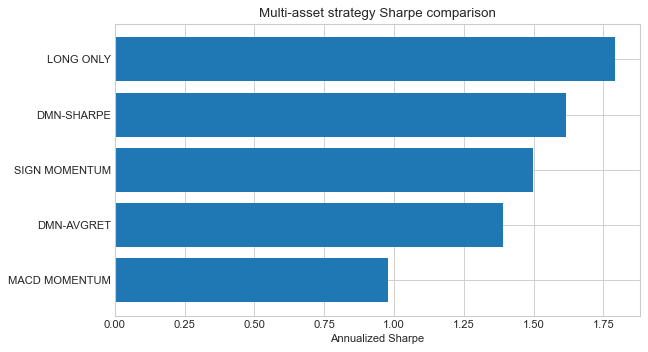

In [26]:
order = multi_metrics.sort_values("Sharpe", ascending=True)
fig, ax = plt.subplots(figsize=(8.2, 4.5))
ax.barh(order["Strategy"], order["Sharpe"])
ax.set_title("Multi-asset strategy Sharpe comparison")
ax.set_xlabel("Annualized Sharpe")
fig.tight_layout()
plt.show()

## 26. Multi-Asset Cumulative Returns and Drawdowns

These two plots show whether the DMN improves the path of portfolio returns and whether it controls drawdowns compared with traditional momentum rules.

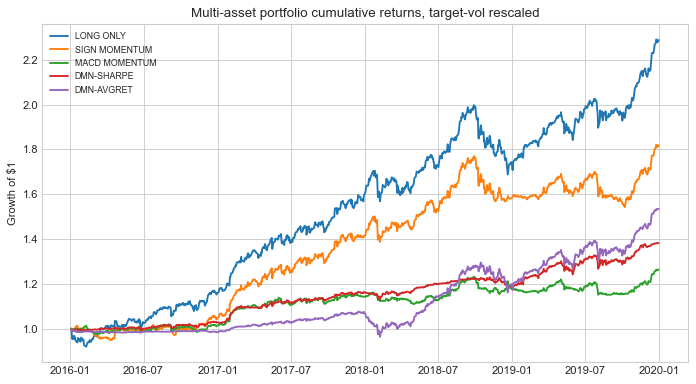

In [27]:
fig, ax = plt.subplots(figsize=(8.8, 4.9))
for label in multi_labels:
    wealth = (1.0 + multi_portfolio_returns[label]).cumprod()
    
    
    ax.plot(multi_portfolio_returns["Date"], wealth, label=label, linewidth=1.7)
ax.set_title("Multi-asset portfolio cumulative returns, target-vol rescaled")
ax.set_ylabel("Growth of $1")


ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

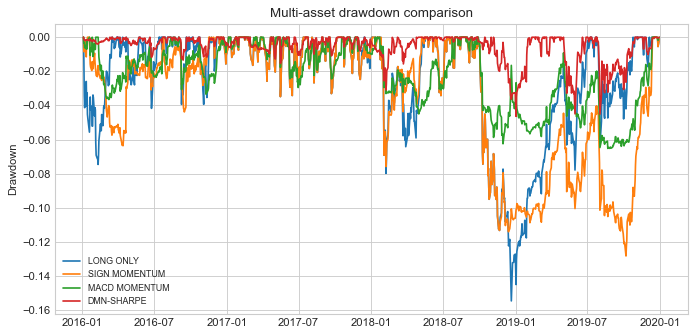

In [28]:
fig, ax = plt.subplots(figsize=(8.8, 4.3))
for label in ["LONG ONLY", "SIGN MOMENTUM", "MACD MOMENTUM", "DMN-SHARPE"]:
    wealth = (1.0 + multi_portfolio_returns[label]).cumprod()
    
    
    drawdown = wealth / wealth.cummax() - 1.0
    ax.plot(multi_portfolio_returns["Date"], drawdown, label=label, linewidth=1.5)
ax.set_title("Multi-asset drawdown comparison")
ax.set_ylabel("Drawdown")


ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()


plt.show()

## 27. Transaction Cost Sensitivity

The paper emphasizes that turnover and transaction costs are a practical limitation of machine-learning trading strategies. Here I test costs from 0 to 5 bps per unit of position turnover.

In [29]:
multi_cost_table

,Strategy,0 bps,1 bps,2 bps,3 bps,5 bps
0,LONG ONLY,1.791400,1.791400,1.791400,1.791400,1.791400
1,SIGN MOMENTUM,1.506341,1.496149,1.485948,1.475740,1.455298
2,MACD MOMENTUM,0.995286,0.979140,0.962993,0.946847,0.914556
3,DMN-SHARPE,1.640658,1.615976,1.591290,1.566600,1.517213
4,DMN-AVGRET,1.405281,1.390231,1.375170,1.360099,1.329926


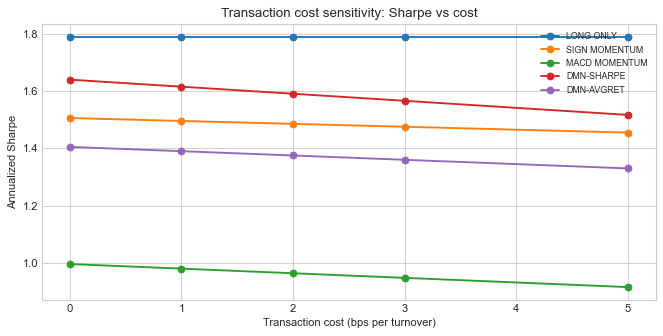

In [30]:
fig, ax = plt.subplots(figsize=(8.4, 4.3))
for _, row in multi_cost_table.iterrows():
    costs = [int(c.split()[0]) for c in multi_cost_table.columns if c.endswith("bps")]
    values = [row[f"{c} bps"] for c in costs]
    
    
    ax.plot(costs, values, marker="o", label=row["Strategy"], linewidth=1.7)
ax.set_title("Transaction cost sensitivity: Sharpe vs cost")


ax.set_xlabel("Transaction cost (bps per turnover)")
ax.set_ylabel("Annualized Sharpe")


ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

## 28. Per-Asset Sharpe Distribution

The paper also studies dispersion across individual assets. This boxplot asks whether performance is coming from one lucky asset or is distributed across the test panel.

/var/folders/89/p1nq1d_j3qddcxk947v3xd640000gn/T/ipykernel_78754/3943224544.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=multi_labels, showmeans=True)


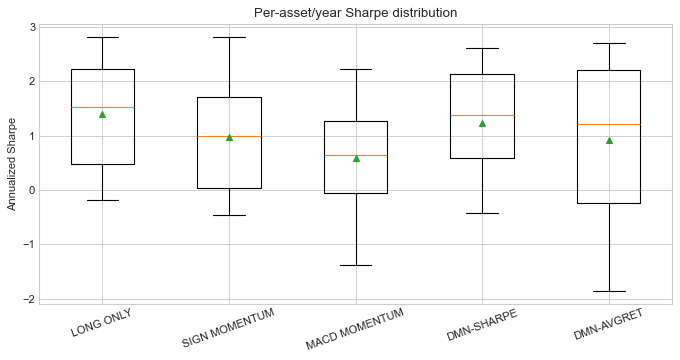

In [31]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))


box_data = [multi_per_asset_sharpe[multi_per_asset_sharpe["Strategy"] == label]["Sharpe"].values for label in multi_labels]
ax.boxplot(box_data, labels=multi_labels, showmeans=True)



ax.set_title("Per-asset/year Sharpe distribution")
ax.set_ylabel("Annualized Sharpe")


ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

## 29. Multi-Asset Position Plot

This plot is useful because it visually proves that the DMN is learning continuous position sizing rather than simply copying the sign rule.

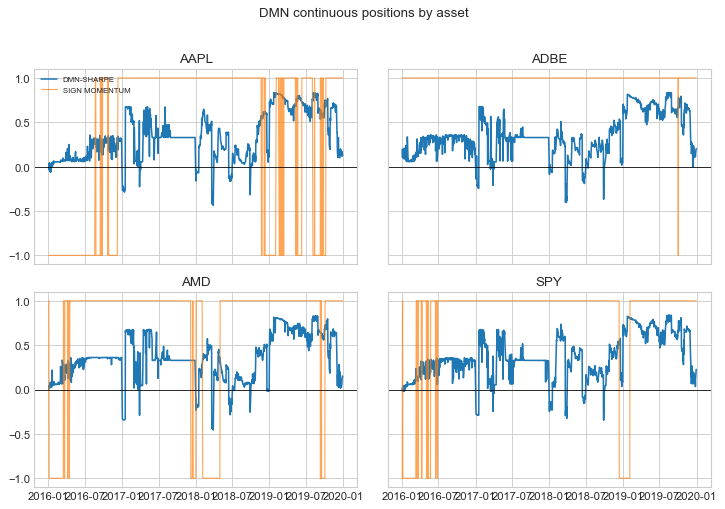

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(9.2, 6.2), sharex=True, sharey=True)
for ax, (asset, group) in zip(axes.ravel(), multi_scored.groupby("Asset")):
    
    
    ax.plot(group["Date"], group["DMN-SHARPE"], label="DMN-SHARPE", linewidth=1.4)
    
    
    ax.plot(group["Date"], group["SIGN MOMENTUM"], label="SIGN MOMENTUM", linewidth=1.0, alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title(asset)
    
    
    ax.set_ylim(-1.1, 1.1)
axes[0, 0].legend(loc="upper left", fontsize=7)



fig.suptitle("DMN continuous positions by asset", y=1.02)
fig.tight_layout()


plt.show()

## 30. Interpretation for the Final Project

The important lesson from the paper is not "deep learning always beats every benchmark." The lesson is more precise:

1. trend following can be written as a position-sizing problem;
2. volatility scaling gives a stable risk target;
3. the neural network can be trained directly on a portfolio objective such as Sharpe;
4. evaluating the strategy requires walk-forward testing, turnover costs, drawdown, and risk-adjusted metrics.

In the SPY-only experiment, long-only SPY is very strong during 2015-2019 because the period is mostly a bull market. The multi-asset section is a stronger validation because it tests the same idea across several real return series with true out-of-sample walk-forward retraining, benchmark comparisons, risk-adjusted metrics, and transaction cost sensitivity.